Source: https://www.kaggle.com/code/bhatnagardaksh/gradient-descent-from-scratch

In [1]:
import numpy as np 
import pandas as pd 
import random 
import seaborn as sns 
import matplotlib.pyplot as plt
import sqlite3 

from sklearn.metrics import r2_score


In [2]:
medical_charges_url = 'https://raw.githubusercontent.com/JovianML/opendatasets/master/data/medical-charges.csv'

medical_df = pd.read_csv(medical_charges_url)
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
medical_df.shape

(1338, 7)

In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
medical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Now we will be doing exploratory data analysis

In [6]:
# creating a sqlite3 database to runs some queries

conn = sqlite3.connect('database.db')

#writing the dataframe to table in the database

medical_df.to_sql('data', conn, if_exists='replace',index=False)

1338

C:\Users\sujat\AppData\Local\Temp\ipykernel_7844\215930058.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


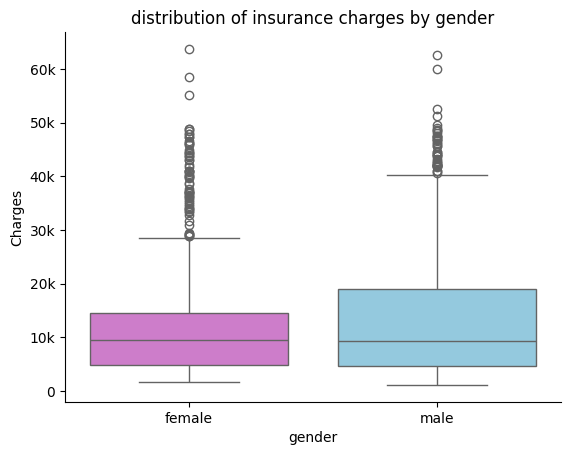

In [7]:
# Define explicit colors for each gender
gender_colors = {'female': 'orchid', 'male': 'skyblue'}

sns.boxplot(data=medical_df, x='sex', y='charges', palette=gender_colors, hue='sex')
yticks = plt.gca().get_yticks()
ylabels = [f"{round(i / 1000)}k" if i != 0 else "0" for i in yticks]
plt.gca().set_yticklabels(ylabels)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.title('distribution of insurance charges by gender')
plt.xlabel('gender')
plt.ylabel('Charges')
plt.show()

males are likely to spend more on insurance charges

C:\Users\sujat\AppData\Local\Temp\ipykernel_7844\2265541650.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


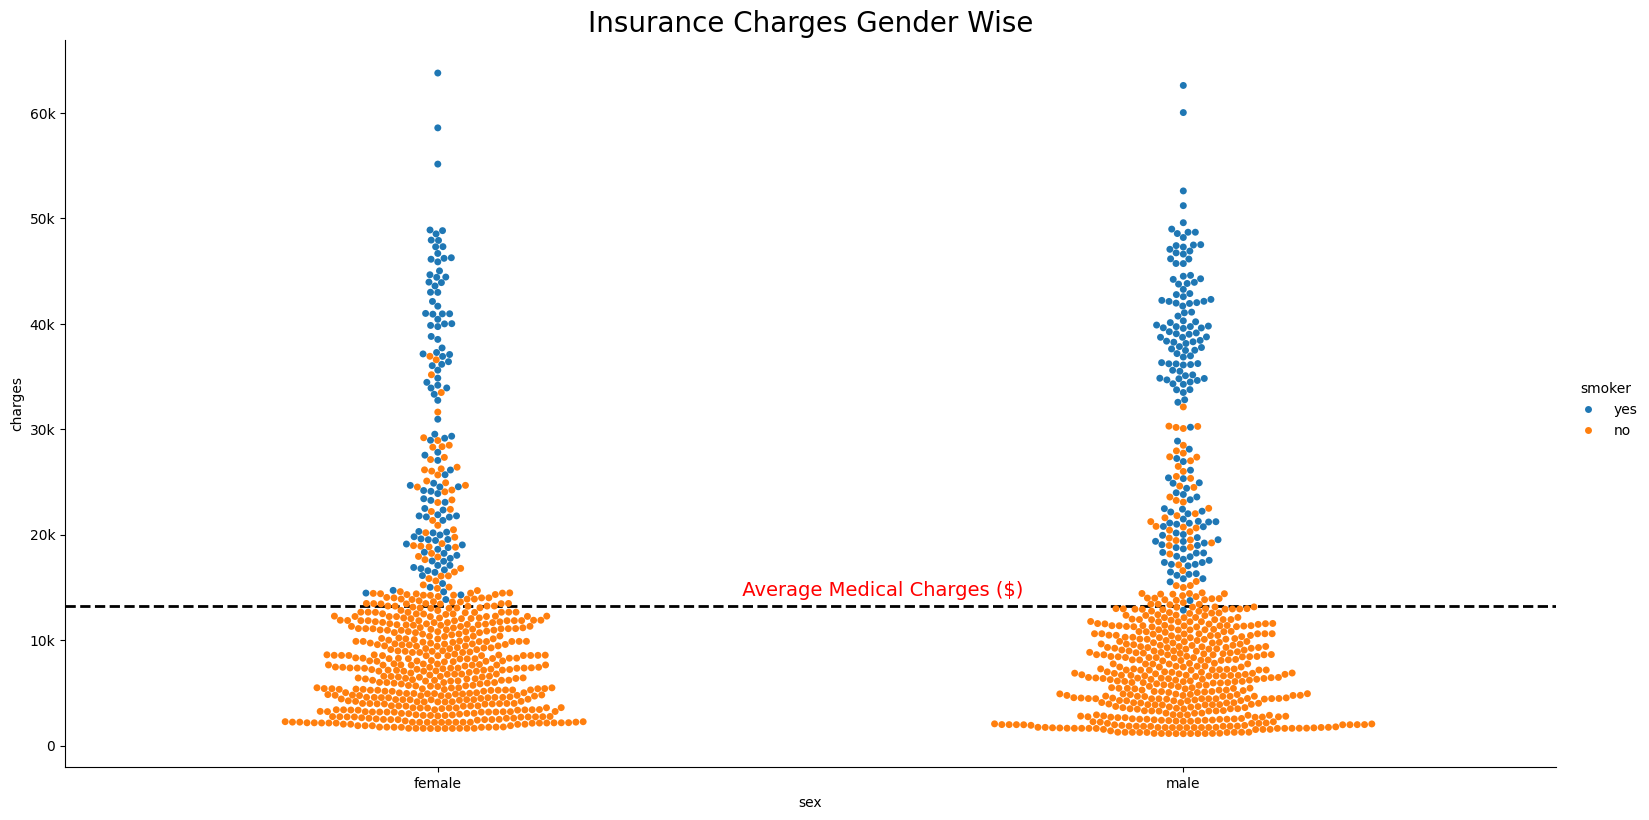

In [8]:
sns.catplot(data=medical_df,x= 'sex',y='charges', kind='swarm', hue='smoker', aspect =2, height=8)
yticks = plt.gca().get_yticks()
ylabels = [f"{round(i / 1000)}k" if i != 0 else "0" for i in yticks]
plt.gca().set_yticklabels(ylabels)
plt.axhline(medical_df['charges'].mean(), linestyle='--', lw=2, zorder=1, color='black')
plt.annotate(f' Average Medical Charges ($)', (.4, medical_df['charges'].mean()+900), fontsize=14,color='red')
plt.title('Insurance Charges Gender Wise', fontsize=20)
plt.show()

interpretation: male smokers are likely to spend more on charges than female smokers

C:\Users\sujat\AppData\Local\Temp\ipykernel_7844\3619732976.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


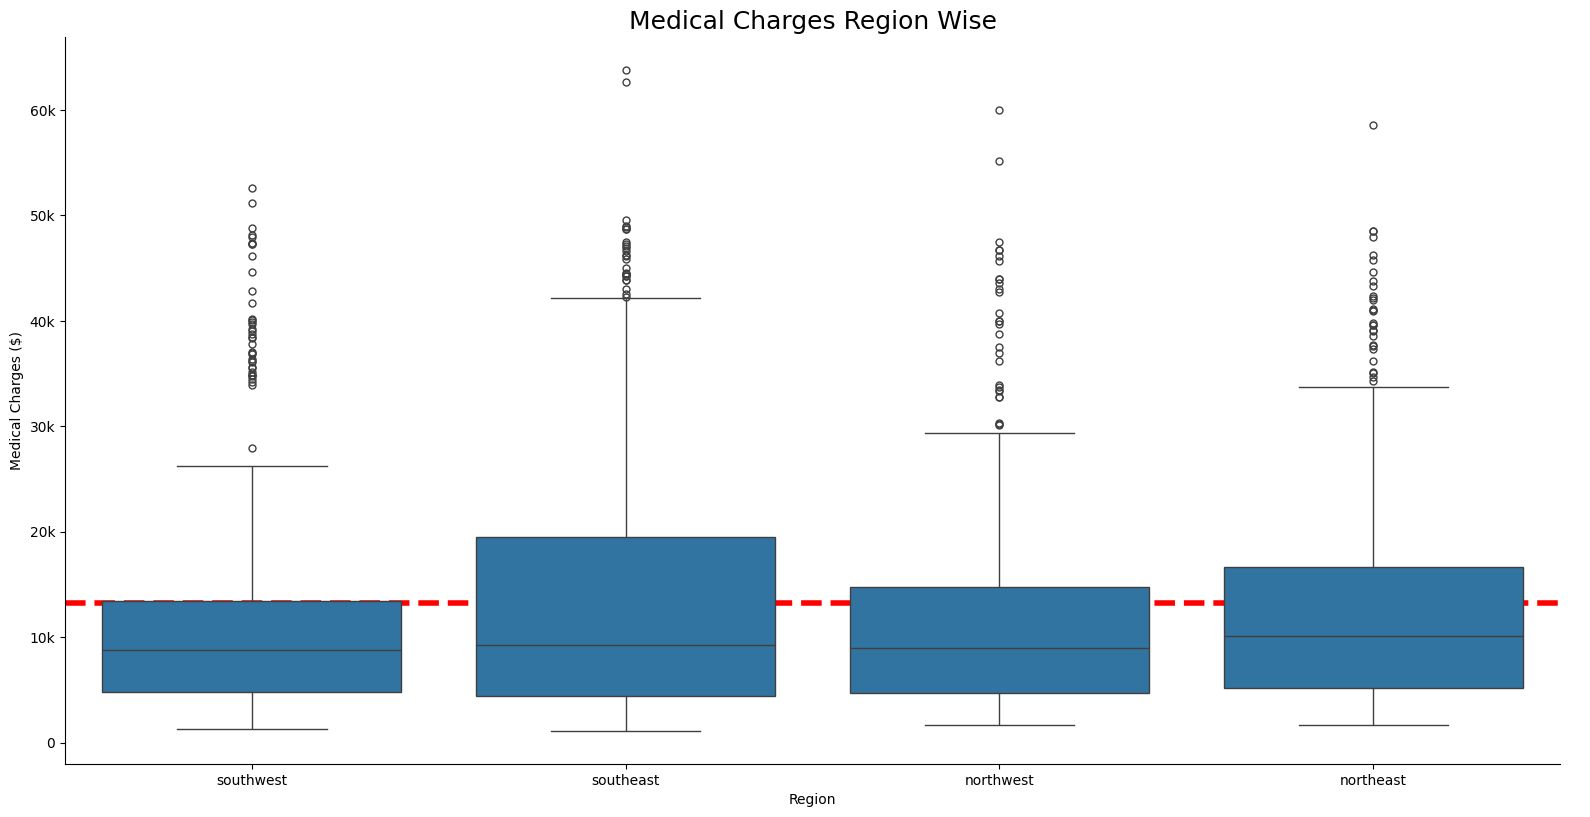

In [9]:
sns.catplot(data=medical_df,x= 'region',y='charges', kind='box', aspect =2, height=8)
yticks = plt.gca().get_yticks()
ylabels = [f"{round(i / 1000)}k" if i != 0 else "0" for i in yticks]
plt.gca().set_yticklabels(ylabels)
plt.axhline(medical_df['charges'].mean(), linestyle='--', lw=4, zorder=1, color='red')
plt.title('Medical Charges Region Wise', fontsize=18)
plt.xlabel('Region')
plt.ylabel('Medical Charges ($)')
plt.show()

INTERPRETATION 

C:\Users\sujat\AppData\Local\Temp\ipykernel_7844\2090630492.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(ylabels)


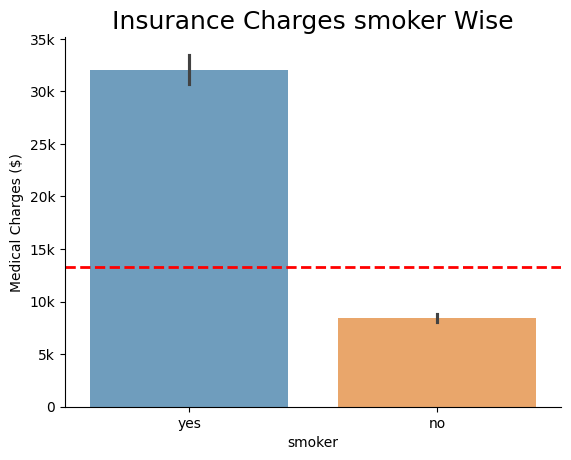

In [10]:
sns.barplot(data=medical_df,x= 'smoker',y='charges', hue='smoker', alpha=0.7, dodge=False)
yticks = plt.gca().get_yticks()
ylabels = [f"{round(i / 1000)}k" if i != 0 else "0" for i in yticks]
plt.gca().set_yticklabels(ylabels)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.axhline(medical_df['charges'].mean(), linestyle='--', lw=2, zorder=1, color='red')
plt.title('Insurance Charges smoker Wise', fontsize=18)
plt.ylabel('Medical Charges ($)')
plt.show()

INTERPRETATION : Smokers end up paying more insurance charges than the ones who don't smoke.